# Złożony workflow – zadania

Zaimplementuj pipeline do **anonimizacji danych osobowych w tekście**. Pipeline powinien:
1. Równolegle wykryć język tekstu i sprawdzić czy zawiera dane osobowe **(równoległe node'y)**
2. Na podstawie wyników zdecydować, czy tekst wymaga anonimizacji **(conditional routing)**
3. Jeśli tak – LLM anonimizuje dane i ponownie sprawdza czy coś zostało pominięte **(cykl)**
4. Zbudować końcowy raport z przetwarzania

## Stan (TypedDict)

1. Zdefiniuj `State` zawierający:
- `text: str` – przetwarzany tekst (może być nadpisany przez node anonimizujący)
- `language: str` – wykryty język
- `pii: dict` – wynik analizy danych osobowych, np. `{"has_pii": bool, "found_items": list[str]}`
- `anonymize_attempts: int` – ile razy próbowano anonimizować tekst
- `is_safe: bool` – czy tekst jest bezpieczny do udostępnienia
- `report: str` – końcowy raport z przetwarzania

---
(czas: 5 min.)

In [14]:
from typing import TypedDict


class State(TypedDict):
    text: str
    language: str
    pii: dict
    anonymize_attempts: int
    is_safe: bool
    report: str

## Funkcje routingu

2. Napisz funkcję routingu `next_after_evaluate(state: State, config: RunnableConfig) -> str`, która:
- pobiera `max_attempts` z `configurable` (domyślnie `2`)
- jeśli `pii["has_pii"]` jest `True` i `anonymize_attempts < max_attempts`: zwraca `"anonymize"`
- w przeciwnym razie: zwraca `"build_report"`

---
(czas: 6 min.)

In [15]:
from langchain_core.runnables import RunnableConfig


def next_after_evaluate(state: State, config: RunnableConfig) -> str:
    max_attempts = config.get("configurable", {}).get("max_attempts", 2)
    if state["pii"]["has_pii"] and state["anonymize_attempts"] < max_attempts:
        return "anonymize"
    return "build_report"

## Node'y

3. Napisz node `start_parallel_node(state: State)`, który nie modyfikuje stanu i służy wyłącznie jako punkt startowy dla równoległych gałęzi. Zwróć pusty słownik `{}`.

---
(czas: 2 min.)

In [16]:
def start_parallel_node(state: State):
    return {}

4. Napisz node `detect_language_node(state: State, config: RunnableConfig)`, który za pomocą LLM wykrywa język tekstu.

Użyj modelu Pydantic z jednym polem `language: str` i metody `with_structured_output`. Zapisz wykryty język (np. `"polski"`, `"angielski"`) do pola `language`.

---
(czas: 10 min.)

In [17]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

load_dotenv()


class LanguageResult(BaseModel):
    language: str = Field(description="Detected language of the text, e.g. Polish, English")


def detect_language_node(state: State, config: RunnableConfig):
    model_name = config.get("configurable", {}).get("model_name", "openai/gpt-4o-mini")
    llm = ChatOpenAI(model=model_name, temperature=0).with_structured_output(LanguageResult)
    response = llm.invoke([
        {"role": "system", "content": "Detect the language of the given text."},
        {"role": "user", "content": state["text"]},
    ])
    return {"language": response.language}

5. Napisz node `check_pii_node(state: State, config: RunnableConfig)`, który za pomocą LLM sprawdza czy tekst zawiera dane osobowe (imiona i nazwiska, adresy e-mail, numery telefonów, adresy, numery PESEL itp.).

Użyj modelu Pydantic z polami `has_pii: bool` i `found_items: list[str]` oraz metody `with_structured_output`. Zapisz wynik jako słownik do pola `pii`.

Ten node jest wywoływany **dwukrotnie** w grafie: raz równolegle z `detect_language`, a następnie ponownie po każdej anonimizacji.

---
(czas: 10 min.)

In [18]:
class PIIResult(BaseModel):
    has_pii: bool = Field(description="Whether the text contains personal data")
    found_items: list[str] = Field(default_factory=list, description="List of personal data items found")


def check_pii_node(state: State, config: RunnableConfig):
    model_name = config.get("configurable", {}).get("model_name", "openai/gpt-4o-mini")
    llm = ChatOpenAI(model=model_name, temperature=0).with_structured_output(PIIResult)
    response = llm.invoke([
        {
            "role": "system",
            "content": (
                "Check whether the text contains personal data: names, surnames, email addresses, "
                "phone numbers, physical addresses, national ID numbers or other identifying information."
            ),
        },
        {"role": "user", "content": state["text"]},
    ])
    return {"pii": response.model_dump()}

6. Napisz node `evaluate_node(state: State)`, który ustawia `is_safe` na `True` jeśli `pii["has_pii"]` wynosi `False`, w przeciwnym razie na `False`.

---
(czas: 3 min.)

In [19]:
def evaluate_node(state: State):
    return {"is_safe": not state["pii"]["has_pii"]}

7. Napisz node `anonymize_node(state: State, config: RunnableConfig)`, który:
- wysyła do LLM polecenie zastąpienia wszystkich danych osobowych odpowiednimi placeholderami (np. `[IMIĘ]`, `[NAZWISKO]`, `[EMAIL]`, `[TELEFON]`, `[ADRES]`)
- nadpisuje `text` zanonimizowaną wersją
- zwiększa `anonymize_attempts` o 1

---
(czas: 8 min.)

In [20]:
def anonymize_node(state: State, config: RunnableConfig):
    model_name = config.get("configurable", {}).get("model_name", "openai/gpt-4o-mini")
    llm = ChatOpenAI(model=model_name, temperature=0)
    response = llm.invoke([
        {
            "role": "system",
            "content": (
                "Replace all personal data in the text with placeholders: "
                "[NAME], [SURNAME], [EMAIL], [PHONE], [ADDRESS], [ID]. "
                "Return only the processed text, no comments."
            ),
        },
        {"role": "user", "content": state["text"]},
    ])
    return {
        "text": response.content,
        "anonymize_attempts": state["anonymize_attempts"] + 1,
    }

8. Napisz node `build_report_node(state: State)`, który formatuje końcowy raport zawierający: przetworzony tekst, wykryty język, listę znalezionych danych osobowych, liczbę prób anonimizacji i status (`bezpieczny` / `wymaga weryfikacji`).

---
(czas: 5 min.)

In [21]:
def build_report_node(state: State):
    status = "safe" if state["is_safe"] else "requires review"
    found = ", ".join(state["pii"].get("found_items", [])) or "none"
    report = (
        f"Language: {state['language']}\n"
        f"Status: {status}\n"
        f"Personal data found: {found}\n"
        f"Anonymization attempts: {state['anonymize_attempts']}\n"
        f"\nProcessed text:\n{state['text']}"
    )
    return {"report": report}

## Graf i uruchomienie

9. Zbuduj `StateGraph` z następującą strukturą:
- `START → start_parallel`
- `start_parallel → detect_language` i `start_parallel → check_pii` (dwie osobne krawędzie – równoległe)
- `detect_language → evaluate` i `check_pii → evaluate`
- `evaluate → conditional (next_after_evaluate) → anonymize` lub `build_report`
- `anonymize → check_pii` (zamknięcie cyklu)
- `build_report → END`

Skompiluj pipeline i wyświetl wizualizację.

---
(czas: 12 min.)

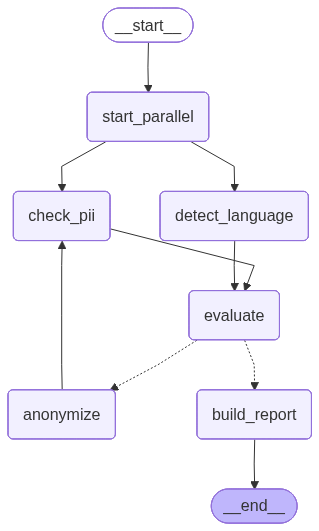

In [22]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END


graph = StateGraph(State)

graph.add_node("start_parallel", start_parallel_node)
graph.add_node("detect_language", detect_language_node)
graph.add_node("check_pii", check_pii_node)
graph.add_node("evaluate", evaluate_node)
graph.add_node("anonymize", anonymize_node)
graph.add_node("build_report", build_report_node)

graph.add_edge(START, "start_parallel")
graph.add_edge("start_parallel", "detect_language")
graph.add_edge("start_parallel", "check_pii")
graph.add_edge("detect_language", "evaluate")
graph.add_edge("check_pii", "evaluate")
graph.add_conditional_edges(
    "evaluate",
    next_after_evaluate,
    {"anonymize": "anonymize", "build_report": "build_report"},
)
graph.add_edge("anonymize", "check_pii")
graph.add_edge("build_report", END)

pipeline = graph.compile()

display(Image(pipeline.get_graph().draw_mermaid_png(), width=200))

10. Uruchom pipeline na trzech różnych tekstach i wypisz `report` z każdego uruchomienia:
- Tekst **bez danych osobowych** (krótka ścieżka bez anonimizacji)
- Tekst **z danymi osobowymi** – np. fragment zgłoszenia z imieniem, emailem i numerem telefonu (widoczny cykl)
- Ten sam tekst z `max_attempts=1` – sprawdź czy po jednej rundzie anonimizacji wszystkie dane zostały usunięte

---
(czas: 8 min.)

In [23]:
runtime_config = {"configurable": {"model_name": "openai/gpt-4o-mini", "max_attempts": 2}}

initial_state = {
    "text": "",
    "language": "",
    "pii": {},
    "anonymize_attempts": 0,
    "is_safe": False,
    "report": "",
}

In [24]:
safe_text = "Order number 4521 was processed and shipped to the customer yesterday."

result = pipeline.invoke({**initial_state, "text": safe_text}, config=runtime_config)
print(result["report"])

Language: English
Status: safe
Personal data found: none
Anonymization attempts: 0

Processed text:
Order number 4521 was processed and shipped to the customer yesterday.


In [25]:
pii_text = (
    "Dzień dobry, nazywam się Anna Kowalska. "
    "Proszę o kontakt pod adresem anna.kowalska@gmail.com lub telefonicznie: 601 234 567. "
    "Mieszkam przy ul. Kwiatowej 12, 00-001 Warszawa."
)

result = pipeline.invoke({**initial_state, "text": pii_text}, config=runtime_config)
print(result["report"])

Language: Polish
Status: requires review
Personal data found: [NAME], [SURNAME], [EMAIL], [PHONE], [ADDRESS]
Anonymization attempts: 2

Processed text:
Dzień dobry, nazywam się [NAME] [SURNAME]. Proszę o kontakt pod adresem [EMAIL] lub telefonicznie: [PHONE]. Mieszkam przy [ADDRESS].


In [26]:
config_1_attempt = {"configurable": {"model_name": "openai/gpt-4o-mini", "max_attempts": 1}}

result = pipeline.invoke({**initial_state, "text": pii_text}, config=config_1_attempt)
print(result["report"])

Language: Polish
Status: requires review
Personal data found: [NAME], [SURNAME], [EMAIL], [PHONE], [ADDRESS]
Anonymization attempts: 1

Processed text:
Dzień dobry, nazywam się [NAME] [SURNAME]. Proszę o kontakt pod adresem [EMAIL] lub telefonicznie: [PHONE]. Mieszkam przy [ADDRESS].
